# Olympic Athlete Events — EDA Practice Notebook

Dataset: `athlete_events.csv` — 271,116 rows, one row per **athlete-event** (so the same
person can appear multiple times: once per event, and duplicated across team events).

**Columns:** `ID, Name, Sex, Age, Height, Weight, Team, NOC, Games, Year, Season, City,
Sport, Event, Medal`

**How to use this notebook:**
1. Run the setup cells to load the data.
2. For each question, first decide (in your head or a comment) *which plot type* fits.
3. Write the code yourself in the empty cell below each question.
4. Add a short written takeaway under each answer — a sentence forcing you to state
   what the plot/number actually tells you is the real practice.


## 0 · Setup & Load

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("semaaabumousa/athlete-eventscsv")
print("Path to dataset files:", path)


100%|██████████| 5.43M/5.43M [00:00<00:00, 68.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/semaaabumousa/athlete-eventscsv/versions/1


In [ ]:
!ls /root/.cache/kagglehub/datasets/semaaabumousa/athlete-eventscsv/versions/1

athlete_events.csv


In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

%matplotlib inline

df = pd.read_csv(os.path.join(path, 'athlete_events.csv'))
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


### Quick  check before diving into questions



In [ ]:
print("Shape:", df.shape)
df.info()


Shape: (271116, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [ ]:
df.isnull().sum()


,0
ID,0
Name,0
Sex,0
Age,9474
Height,60171
Weight,62875
Team,0
NOC,0
Games,0
Year,0


In [ ]:
# Medal is expected to be mostly missing (only top-3 per event get one) —so null values mea no medal
df["Medal"].value_counts(dropna=False)


,count
Medal,
NaN,231333
Gold,13372
Bronze,13295
Silver,13116


> **Tip:** Decide now whether you'll work with the raw row-per-athlete-per-event table,
> or a deduplicated version (e.g., one row per unique `(Name, Team, Games, Event)` for
> medal counts, since team events give every team member the same medal row). Some
> questions below need one, some need the other — think about which as you go.


# Data Cleaning

# Explore if Age columns was missed due( MCAR missed completely at random , MAR missed at random , or not missed at random )


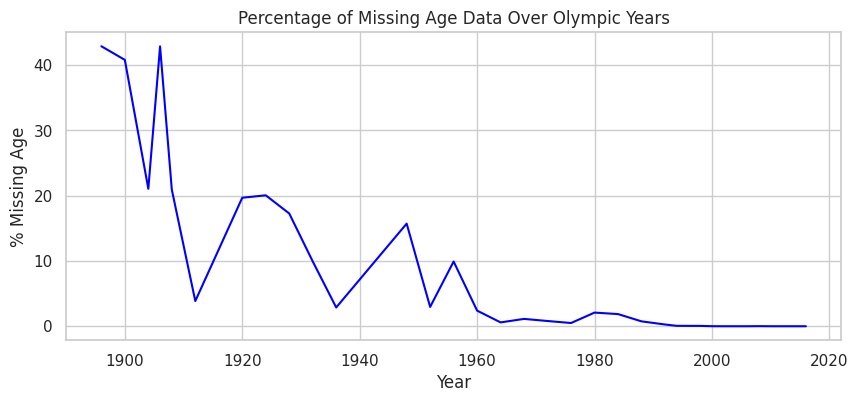

In [ ]:
# explain with visualization
missing_age_year = df['Age'].isnull().groupby(df['Year']).mean() * 100

plt.figure(figsize=(10, 4))
sns.lineplot(x=missing_age_year.index, y=missing_age_year.values, color='blue')
plt.title('Percentage of Missing Age Data Over Olympic Years')
plt.ylabel('% Missing Age')
plt.xlabel('Year')
plt.show()

In [ ]:
# The missing age is MAR (Missing At Random) because it heavily depends on the 'Year'.

# Explore if weight column is missed due( MCAR missed completely at random , MAR missed at random , or not missed at random )

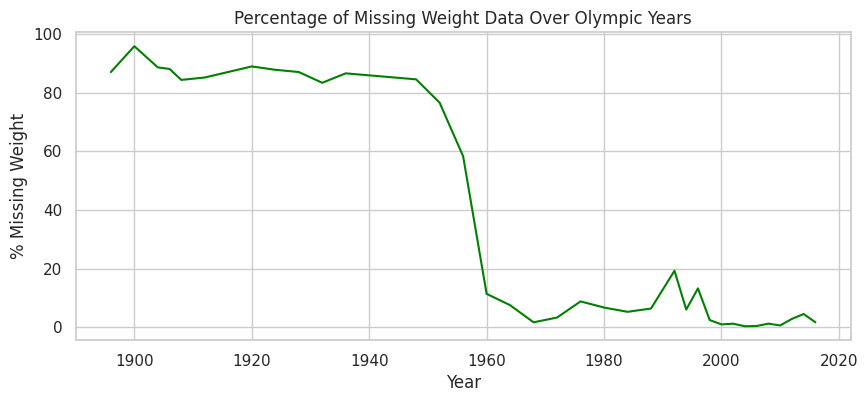

In [ ]:
# explain with visualization
missing_weight_year = df['Weight'].isnull().groupby(df['Year']).mean() * 100

plt.figure(figsize=(10, 4))
sns.lineplot(x=missing_weight_year.index, y=missing_weight_year.values, color='green')
plt.title('Percentage of Missing Weight Data Over Olympic Years')
plt.ylabel('% Missing Weight')
plt.xlabel('Year')
plt.show()

In [ ]:
#Weight is MAR.

# Explore if Height column is missed due( MCAR missed completely at random , MAR missed at random , or not missed at random )

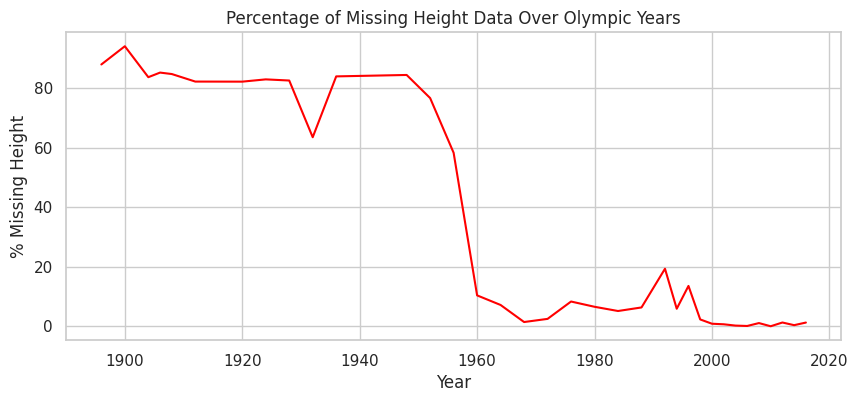

In [ ]:
# explain with visualization
missing_height_year = df['Height'].isnull().groupby(df['Year']).mean() * 100

plt.figure(figsize=(10, 4))
sns.lineplot(x=missing_height_year.index, y=missing_height_year.values, color='red')
plt.title('Percentage of Missing Height Data Over Olympic Years')
plt.ylabel('% Missing Height')
plt.xlabel('Year')
plt.show()

In [ ]:
# Height is MAR (Missing At Random)

# Discuss the best way to impute each column  

In [ ]:
### age
# The best approach is to impute using the median age grouped by Sport and Sex. Different sports have different peak ages.


#### weight
# Impute using the median weight grouped by Sport and Sex (and ideally Event if weight classes are involved, like in Judo or Wrestling)


### height
# impute using the median height grouped by Sport and Sex



---
## 1 · Descriptive / Warm-up




**Q1. What is the age, height, and weight distribution of Olympic athletes overall — is it symmetric or skewed?**

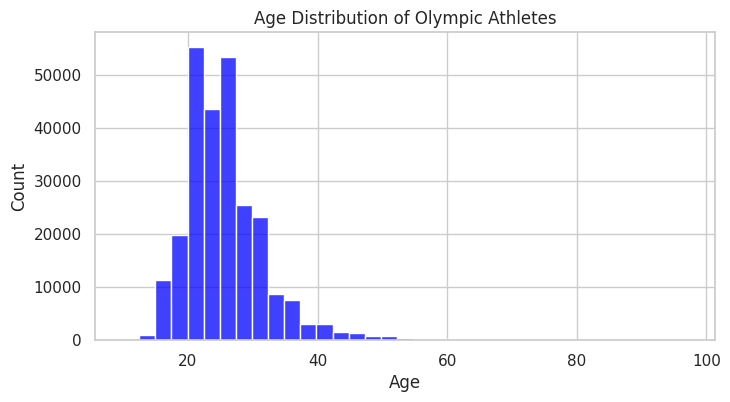

In [ ]:
### age
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'].dropna(), bins=35, color='blue')
plt.title('Age Distribution of Olympic Athletes')
plt.xlabel('Age')
plt.show()


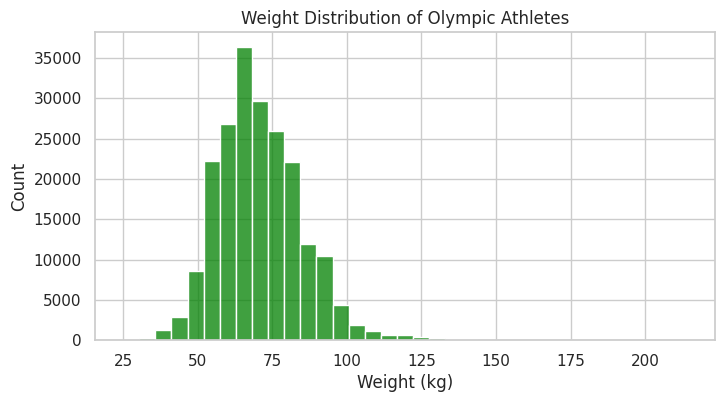

In [ ]:
#### weight
plt.figure(figsize=(8, 4))
sns.histplot(df['Weight'].dropna(), bins=35, color='green')
plt.title('Weight Distribution of Olympic Athletes')
plt.xlabel('Weight (kg)')
plt.show()




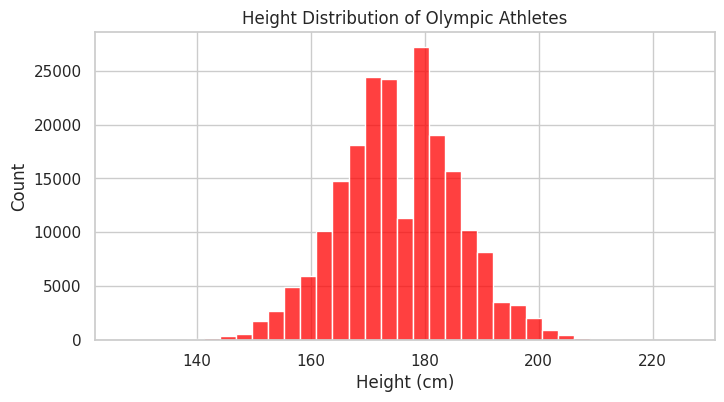

In [ ]:
### height
plt.figure(figsize=(8, 4))
sns.histplot(df['Height'].dropna(), bins=35, color='red')
plt.title('Height Distribution of Olympic Athletes')
plt.xlabel('Height (cm)')
plt.show()



**Q2. How has the number of participating athletes changed across Olympic Games over the years?**
*you need first to compute number of participants per year(treat summer and winter separately )


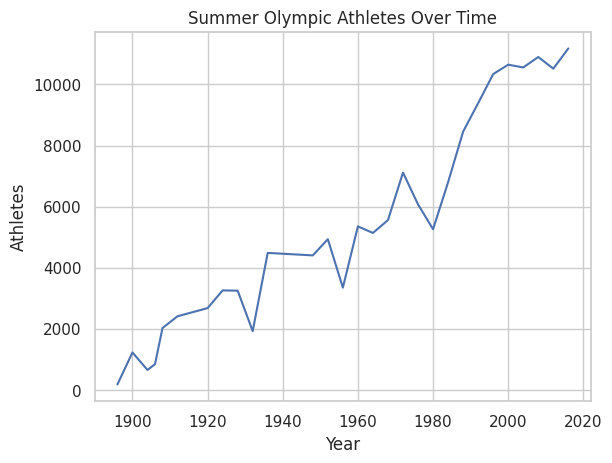

In [ ]:
# summer
summer_data = df[df['Season'] == 'Summer']
summer_counts = summer_data.groupby('Year')['ID'].nunique()

sns.lineplot(x=summer_counts.index, y=summer_counts.values)
plt.title('Summer Olympic Athletes Over Time')
plt.xlabel('Year')
plt.ylabel('Athletes')
plt.show()



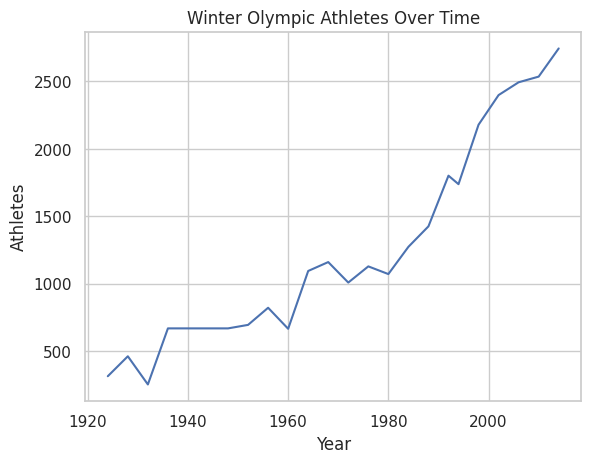

In [ ]:
# winter
winter_data = df[df['Season'] == 'Winter']
winter_counts = winter_data.groupby('Year')['ID'].nunique()

sns.lineplot(x=winter_counts.index, y=winter_counts.values)
plt.title('Winter Olympic Athletes Over Time')
plt.xlabel('Year')
plt.ylabel('Athletes')
plt.show()



**Q3. What proportion of records actually have a medal (Gold/Silver/Bronze) vs. no medal — does that match expectations?**
*Plot idea: count plot


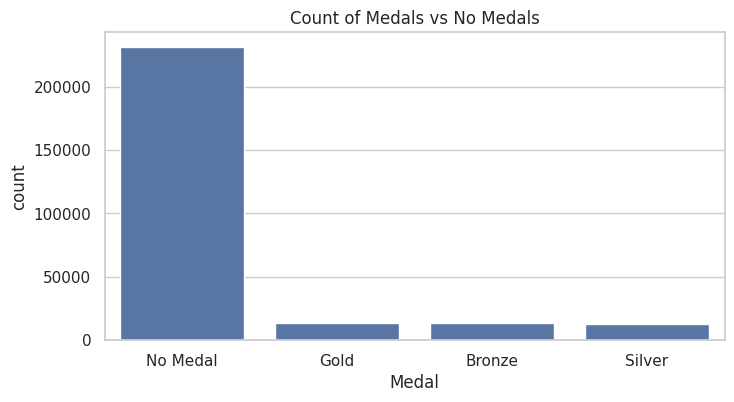

In [ ]:
# write your code here
medal_counts = df['Medal'].fillna('No Medal')

plt.figure(figsize=(8, 4))
sns.countplot(x=medal_counts)
plt.title('Count of Medals vs No Medals')
plt.show()


---


**Q4. Do male and female athletes differ in average height and weight? Does the gap change across sports?**




         Height     Weight
Sex                       
F    167.839740  60.021252
M    178.858463  75.743677


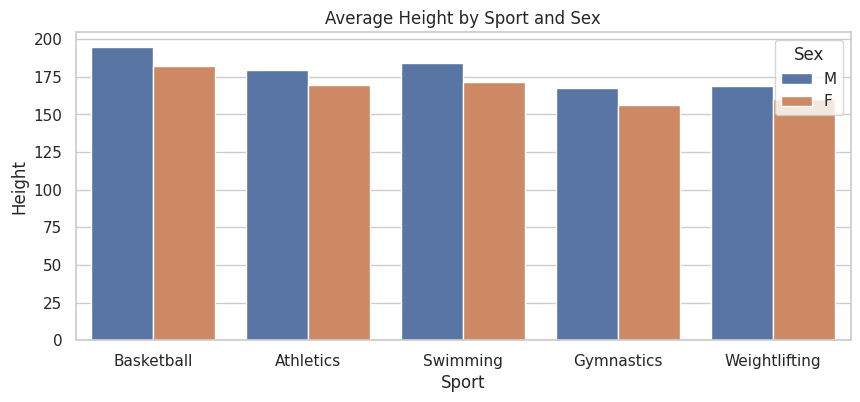

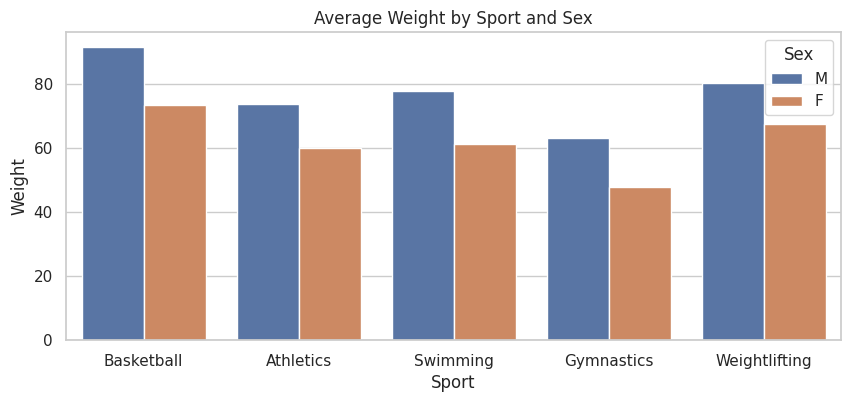

In [ ]:
# write your code here
print(df.groupby('Sex')[['Height', 'Weight']].mean())
sample_sports = ['Basketball', 'Gymnastics', 'Athletics', 'Swimming', 'Weightlifting']
df_sports = df[df['Sport'].isin(sample_sports)]

plt.figure(figsize=(10, 4))
sns.barplot(data=df_sports, x='Sport', y='Height', hue='Sex', errorbar=None)
plt.title('Average Height by Sport and Sex')
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=df_sports, x='Sport', y='Weight', hue='Sex', errorbar=None)
plt.title('Average Weight by Sport and Sex')
plt.show()



**Q5. Do Summer and Winter Olympic athletes differ in physical attributes (age, height, weight)?**


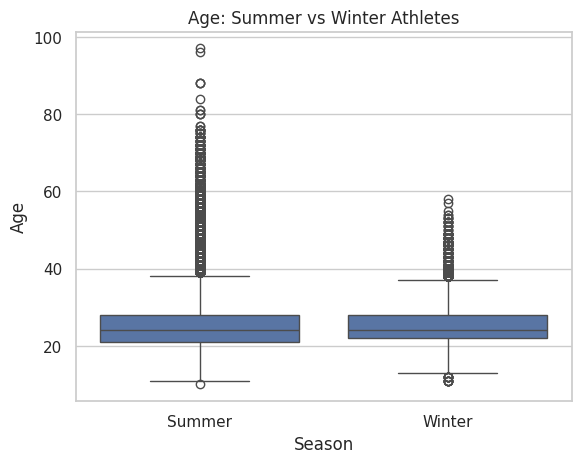

In [ ]:
# write your code here
# Age
sns.boxplot(data=df, x='Season', y='Age')
plt.title('Age: Summer vs Winter Athletes')
plt.show()



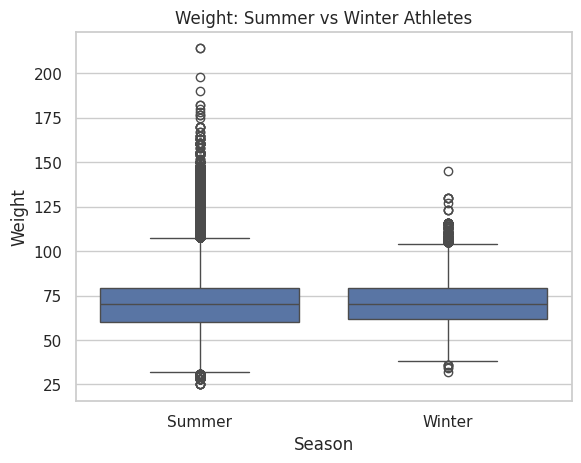

In [ ]:
# weight
sns.boxplot(data=df, x='Season', y='Weight')
plt.title('Weight: Summer vs Winter Athletes')
plt.show()



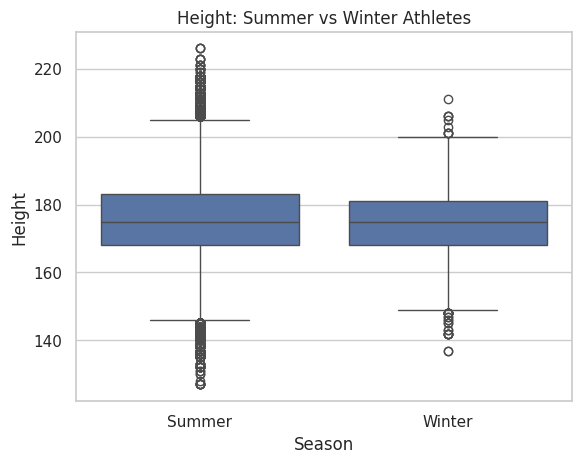

In [ ]:
# height
sns.boxplot(data=df, x='Season', y='Height')
plt.title('Height: Summer vs Winter Athletes')
plt.show()



##Q6. How has the gender balance (proportion of male vs. female athletes) changed from 1896 to today?**
* hint: across time so best plot could be a line plot


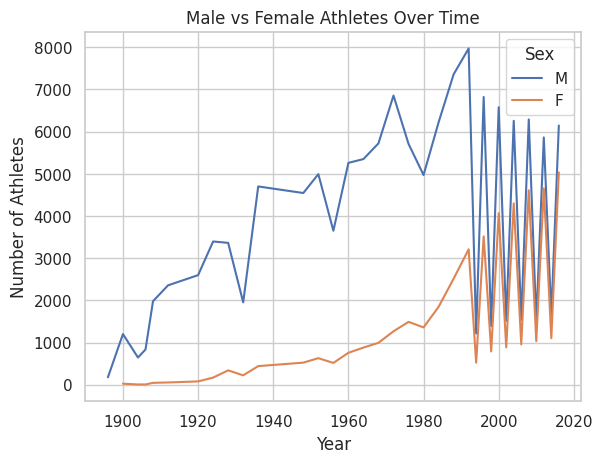

In [ ]:
# write your code here
gender_counts = df.groupby(['Year', 'Sex'])['ID'].nunique().reset_index()

sns.lineplot(data=gender_counts, x='Year', y='ID', hue='Sex')
plt.title('Male vs Female Athletes Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Athletes')
plt.show()




##Q7. Does host-country advantage show up in the data — do host nations win more medals in the year they host?
** take Germany as example and compute number of medals each year , highlighting the host year




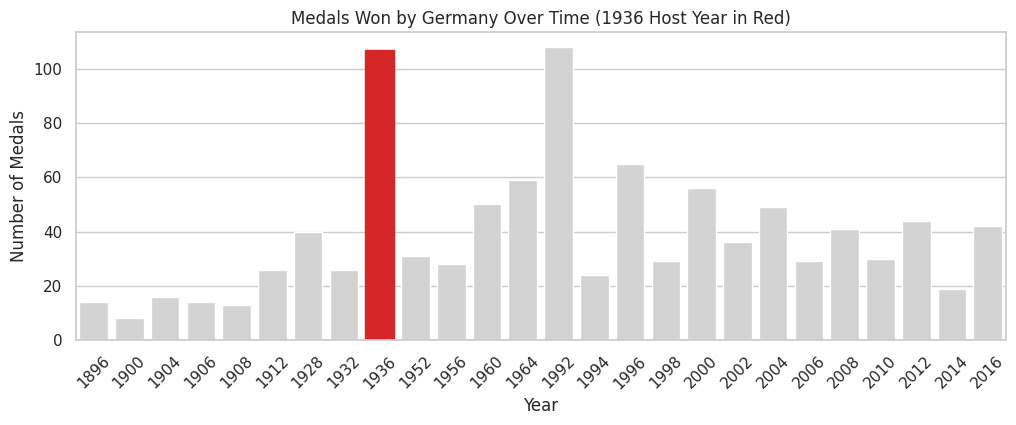

In [ ]:
# write your code here
germany_medals = df[(df['NOC'] == 'GER') & (df['Medal'].notnull())]
germany_medals = germany_medals.drop_duplicates(subset=['Year', 'Event', 'Medal'])
germany_counts = germany_medals.groupby('Year').size().reset_index(name='Medal_Count')

plt.figure(figsize=(12, 4))
ax = sns.barplot(data=germany_counts, x='Year', y='Medal_Count', color='lightgray')
host_year_index = germany_counts[germany_counts['Year'] == 1936].index[0]
ax.patches[host_year_index].set_color('tab:red')

plt.title('Medals Won by Germany Over Time (1936 Host Year in Red)')
plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.xticks(rotation=45)
plt.show()







##Q8. Is there a relationship between an athlete's height and the sport they compete in (e.g., basketball vs. gymnastics)?


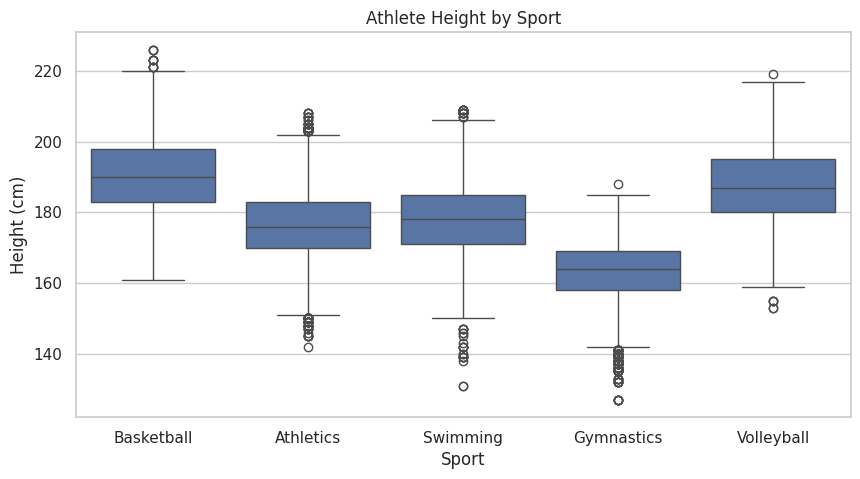

In [4]:
# write your code here
selected_sports = ['Basketball', 'Volleyball', 'Swimming', 'Athletics', 'Gymnastics']
df_selected = df[df['Sport'].isin(selected_sports)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_selected, x='Sport', y='Height')
plt.title('Athlete Height by Sport')
plt.xlabel('Sport')
plt.ylabel('Height (cm)')
plt.show()


##Q9. Is there a relationship between age and medal-winning likelihood — do athletes peak at a certain age, and does that differ by sport?


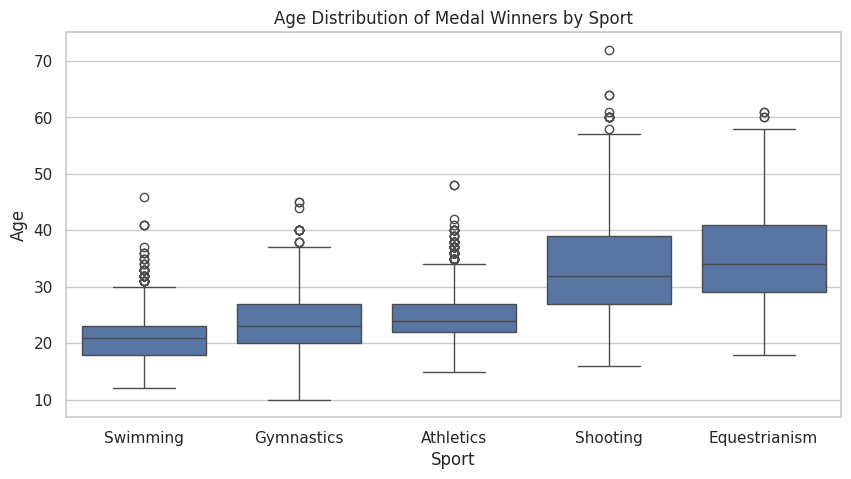

In [5]:
# write your code here
medals_df = df[df['Medal'].notnull()]
peak_sports = ['Gymnastics', 'Swimming', 'Athletics', 'Shooting', 'Equestrianism']
df_peak = medals_df[medals_df['Sport'].isin(peak_sports)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_peak, x='Sport', y='Age')
plt.title('Age Distribution of Medal Winners by Sport')
plt.xlabel('Sport')
plt.ylabel('Age')
plt.show()

---
##  · Ranking / "Who Dominates"
**Q10. Which countries (NOC) have won the most total medals across all Games?**


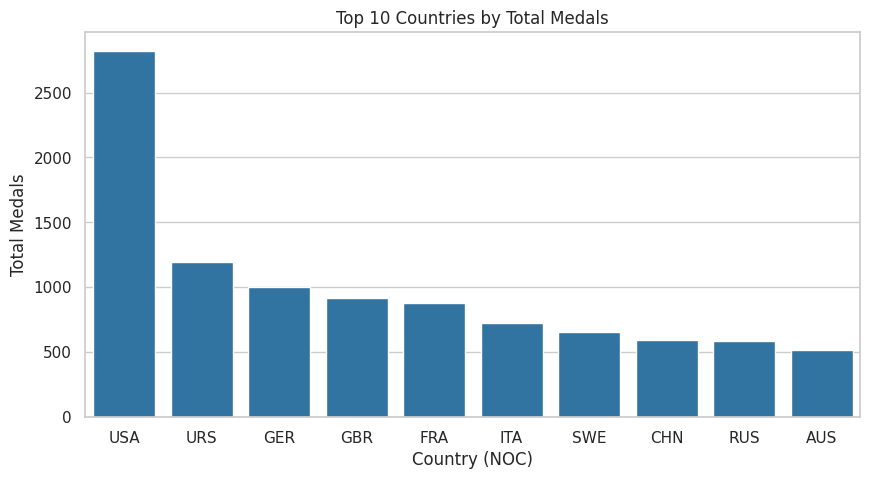

In [6]:
# write your code here
medals_df = df[df['Medal'].notnull()]
unique_medals = medals_df.drop_duplicates(subset=['Year', 'Event', 'Medal', 'NOC'])
top_countries = unique_medals['NOC'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.index, y=top_countries.values, color='tab:blue')
plt.title('Top 10 Countries by Total Medals')
plt.xlabel('Country (NOC)')
plt.ylabel('Total Medals')
plt.show()


**Q11. Which sports/events does each dominant country specialize in?** # take two dominant countries as example


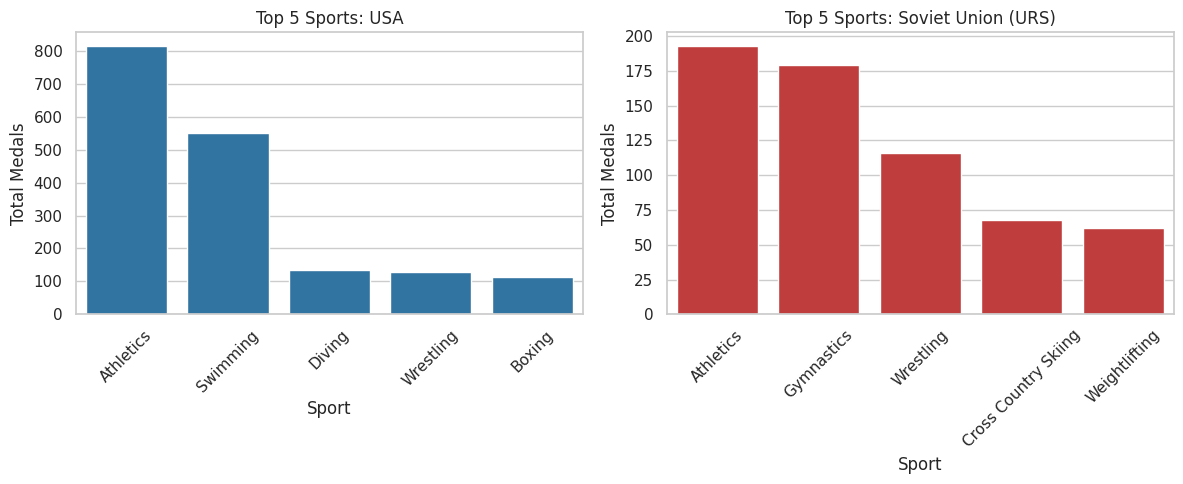

In [7]:
# write your code here
usa_top = unique_medals[unique_medals['NOC'] == 'USA']['Sport'].value_counts().head(5)
urs_top = unique_medals[unique_medals['NOC'] == 'URS']['Sport'].value_counts().head(5)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=usa_top.index, y=usa_top.values, color='tab:blue')
plt.title('Top 5 Sports: USA')
plt.ylabel('Total Medals')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x=urs_top.index, y=urs_top.values, color='tab:red')
plt.title('Top 5 Sports: Soviet Union (URS)')
plt.ylabel('Total Medals')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Q14. Which sport has the widest range of athlete ages, and which has the narrowest (most age-restrictive in practice)?**
consider sorting sports by IQR and showing only the extremes.*


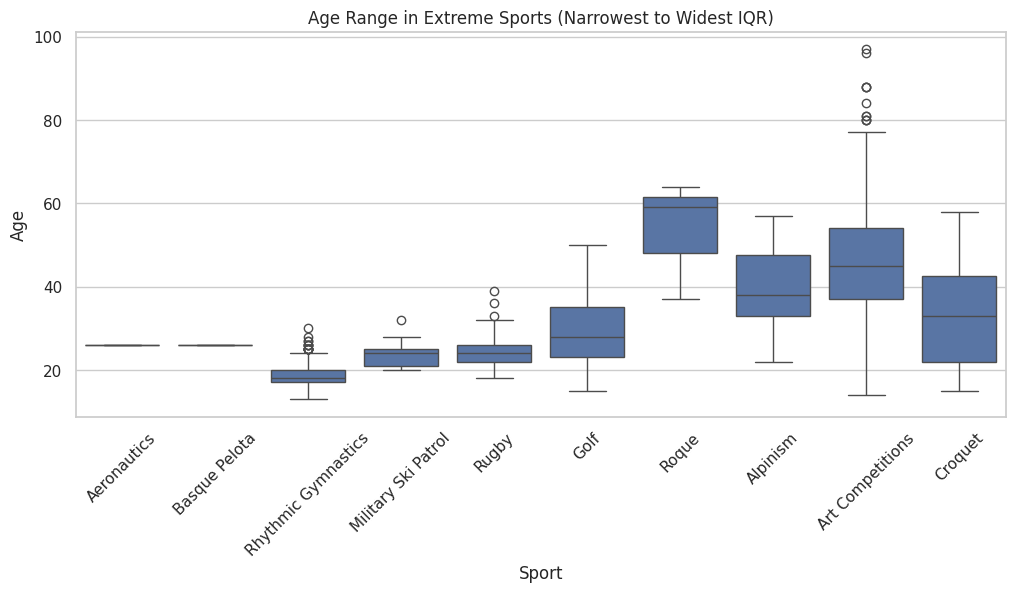

In [8]:
# write your code here
sport_iqr = df.groupby('Sport')['Age'].apply(lambda x: x.quantile(0.75) - x.quantile(0.25)).dropna()
sport_iqr_sorted = sport_iqr.sort_values()
narrowest_sports = sport_iqr_sorted.head(5)
widest_sports = sport_iqr_sorted.tail(5)
extreme_sports = list(narrowest_sports.index) + list(widest_sports.index)
df_extreme = df[df['Sport'].isin(extreme_sports)]

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_extreme, x='Sport', y='Age', order=extreme_sports)
plt.title('Age Range in Extreme Sports (Narrowest to Widest IQR)')
plt.xlabel('Sport')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.show()

---
## Wrap-up

Once you've worked through these, write 3-5 bullet points summarizing the most
interesting or surprising findings — that summary is the actual deliverable of an EDA,
not the plots themselves.


In [ ]:
# Missing Data: The missing age, height, and weight data isn't a random error. It's mostly missing from the really old Olympics just because they didn't record it well back then.
# More Athletes & Women: The number of athletes grew a lot over the years, and women's participation went from basically zero to being equal with men.
# Host Advantage: Hosting the games gives a huge boost. Countries win way more medals when the Olympics are in their own country.